probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [11]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [12]:
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Unit tests on basis functions

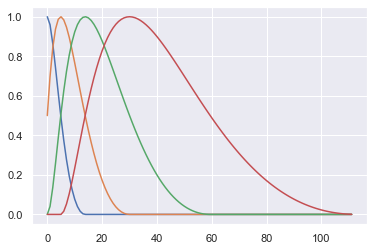

(112, 4)

In [13]:
pillow_basis = GLM.make_pillow_basis(peaks_max=30, num=4, nonlinear=0.2, verbose=True)
pillow_basis.shape

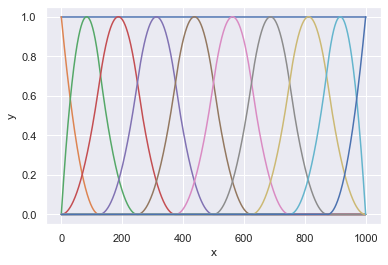

(1000, 11)

In [14]:
basis = GLM.make_b_spline_basis(10, add_constant_basis=True, verbose=True)
basis.shape

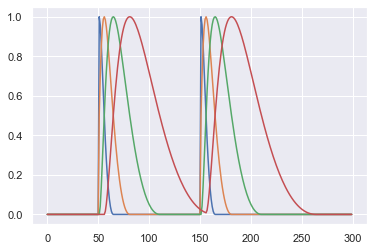

In [15]:
spike = np.zeros(300)
spike[50] = 1
spike[150] = 1

X = GLM.conv(spike, pillow_basis)
plt.plot(X)

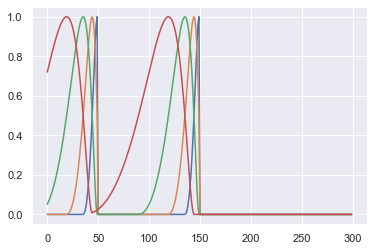

In [16]:
X = GLM.conv_flip(spike, pillow_basis)
plt.plot(X)

(5000, 11)

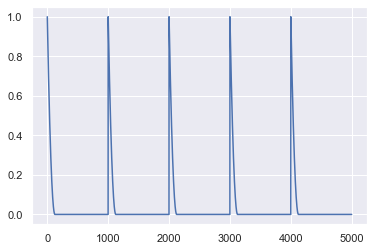

In [17]:
X = GLM.inhomo_baseline(end=1000, ntrial=5)
plt.plot(X[:,1])
X.shape

# K-means on neurons

In [18]:
import pickle
with open('membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [19]:
membership[0]

,probe,group_id
unit_ids,,
951800803,probeC,0
951800819,probeC,1
951800831,probeC,2
951800909,probeC,1
951800900,probeC,2
...,...,...
951819836,probeE,0
951819902,probeE,1
951820372,probeE,2


In [20]:
condition_ids

[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270]

# Load data

In [21]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.1
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeC','probeD','probeE'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

D:\Anaconda3\lib\site-packages\allensdk\brain_observatory\comparison_utils.py:9: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  from pandas.util.testing import assert_frame_equal


Download time: 1200


D:\Anaconda3\lib\site-packages\allensdk\brain_observatory\ecephys\stimulus_table\naming_utilities.py:146: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
D:\Anaconda3\lib\site-packages\allensdk\brain_observatory\ecephys\ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


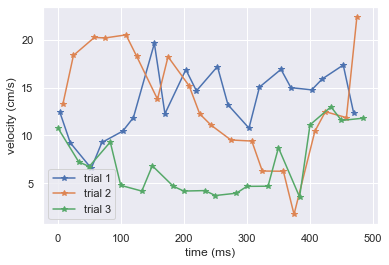

In [22]:
all_time = V1._session.running_speed['mean_time']
all_v = V1._session.running_speed['velocity']
time_list = [1586.1, 1592.1, 1622.1]
for time in time_list:
    idx = (all_time<time+0.5) & (all_time>time)
    plt.plot((all_time[idx]-time)*1000,all_v[idx] , '-*')
    plt.xlabel('time (ms)')
    plt.ylabel('velocity (cm/s)')
    plt.legend(('trial 1', 'trial 2', 'trial 3'))

# PTSH

<ipython-input-23-5e0d54bf94a5>:41: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  fig_coupling.add_subplot(gs_coupling[0, 0])


Text(0.5, 0.98, 'Smoothed PSTH of a population (spikes per ms)')

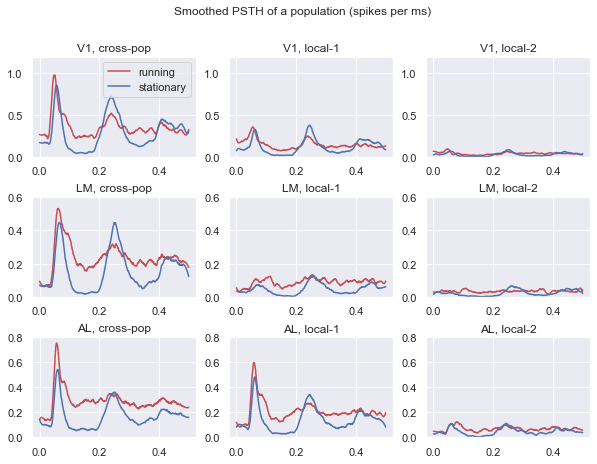

In [23]:
from scipy.signal import savgol_filter
import seaborn as sns
sns.set_theme()

smooth_window = 31
smooth_poly = 3
fig_coupling = plt.figure(figsize=(10,7))
plt.rcParams['font.size'] = '10'
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.4)

gs_coupling = fig_coupling.add_gridspec(3, 3)
# fig_baseline = plt.figure(figsize=(10,7))
# gs_baseline = fig_baseline.add_gridspec(9, 9)

group_name = ['cross-pop', 'local-1', 'local-2']
probe_area = {'probeC':'V1', 'probeD':'LM', 'probeE':'AL'}
ymax = [1.2,0.6,0.8]
iplot = 0
jplot = 0
pillow_basis = GLM.make_pillow_basis(peaks_max=30, num=4, nonlinear=0.2, verbose=False)
pillow_basis_speed = GLM.make_pillow_basis(peaks_max=10, num=2, nonlinear=0.5, verbose=False)
X_baseline = GLM.inhomo_baseline(ntrial=V1.ntrial, start=0, end=V1.nt, dt=1, num=10)
for input_probe in V1.selected_probes:
    for input_group_id in range(3):
        
        fig_coupling.add_subplot(gs_coupling[iplot, jplot])
        input_spike = utils.pooling_pop(membership, condition_ids, V1, input_probe, input_group_id, spike_train=True)
        
        x = V1.time_line
        y = input_spike[:,V1.running_trial_index].mean(axis=1)
        plt.plot(x, savgol_filter(y, smooth_window, smooth_poly), 'r',label='running')
        
        x = V1.time_line
        y = input_spike[:,V1.stationary_trial_index].mean(axis=1)
        plt.plot(x, savgol_filter(y, smooth_window, smooth_poly), 'b', label='stationary')
        plt.title(f"{probe_area[input_probe]}, {group_name[jplot]}")
        plt.ylim(0,ymax[iplot])
        jplot += 1
    iplot += 1
    jplot = 0
fig_coupling.add_subplot(gs_coupling[0, 0])
plt.legend()
plt.suptitle("Smoothed PSTH of a population (spikes per ms)")

# A simple example / unit test

D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


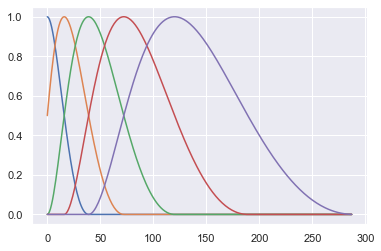

In [24]:
import statsmodels.api as sm

pillow_basis = GLM.make_pillow_basis(peaks_max=120, num=5, nonlinear=0.3, verbose=True)
X_baseline = GLM.inhomo_baseline(ntrial=V1.ntrial, start=0, end=V1.nt, dt=1, num=10)
input_spike = utils.pooling_pop(membership, condition_ids, V1, 'probeC', 0)
output_spike = utils.pooling_pop(membership, condition_ids, V1, 'probeD', 0)
X_coupling = GLM.conv(input_spike, pillow_basis)
response = output_spike.flatten('F')
predictors = np.hstack((X_baseline, X_coupling))

results = sm.GLM(response, predictors, family=sm.families.Poisson()).fit()

In [25]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:               105000
Model:                            GLM   Df Residuals:                   104985
Model Family:                 Poisson   Df Model:                           14
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -49083.
Date:                Sun, 26 Jun 2022   Deviance:                       63041.
Time:                        10:45:49   Pearson chi2:                 1.04e+05
No. Iterations:                     6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2356      0.018   -124.125      0.000      -2.271      -2.200
x1            -1.1328      0.080    -14.227      0.000      -1.289      -0.977
x2             0.0099      0.038      0.258      0.796      -0.065       0.085
x3             0.2150      0.030      7.232      0.000       0.157       0.273
x4            -0.6812      0.042    -16.339      0.000      -0.763      -0.599
x5             0.0906      0.030      3.041      0.002       0.032       0.149
x6            -0.0751      0.027     -2.763      0.006      -0.128      -0.022
x7            -0.2727      0.034     -8.133      0.000      -0.338      -0.207
x8            -0.1338      0.032     -4.214      0.000      -0.196      -0.072
x9            -0.0376      0.034     -1.107      0.268      -0.104       0.029
x10           -0.4415      0.049     -9.027      0.000      -0.537      -0.346
x11            0.1016      0.003     29.645      0.000       0.095       0.108
x12           -0.0296      0.004     -8.125      0.000      -0.037      -0.022
x13            0.0352      0.003     11.695      0.000       0.029       0.041
x14           -0.0190      0.002     -9.056      0.000      -0.023      -0.015
x15            0.0053      0.001      5.623      0.000       0.003       0.007
==============================================================================
"""

In [26]:
results.params, results.bse, results.aic

(array([-2.23562079, -1.13282341,  0.00991302,  0.2150004 , -0.681197  ,
         0.09060911, -0.07509196, -0.27270192, -0.13379567, -0.03758468,
        -0.44146525,  0.10159084, -0.02959356,  0.03516293, -0.01899154,
         0.00532179]),
 array([0.01801097, 0.0796233 , 0.03836695, 0.02973056, 0.04169126,
        0.02979506, 0.02717512, 0.03353179, 0.03174959, 0.03395614,
        0.04890687, 0.00342691, 0.00364215, 0.00300667, 0.00209707,
        0.00094648]),
 98196.99754936146)

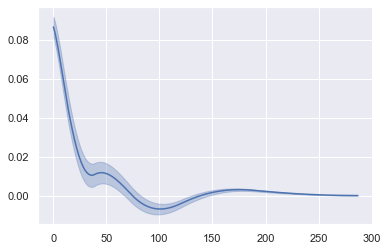

In [27]:
nbasis = pillow_basis.shape[1]
utils.plot_filter(pillow_basis, results.params[-nbasis:], results.bse[-nbasis:], label=None, color='b')

# Fit running and Stationary seperetely WITH speed effects

In [28]:
# test Poisson GLM
import statsmodels.api as sm

selec_trials = V1.running_trial_index

pillow_basis_coupling = GLM.make_pillow_basis(peaks_max=150, num=5, nonlinear=0.2, verbose=False)
pillow_basis = GLM.make_pillow_basis(peaks_max=100, num=3, nonlinear=0.4, verbose=False)

X_baseline = GLM.inhomo_baseline(ntrial=selec_trials.sum(), start=0, end=V1.nt, dt=1, num=10)
input_spike = utils.pooling_pop(membership, condition_ids, V1, 'probeC', 0)[:,selec_trials]
output_spike = utils.pooling_pop(membership, condition_ids, V1, 'probeD', 0)[:,selec_trials]
X_coupling = GLM.conv(input_spike, pillow_basis_coupling)
X_speed_pos = GLM.conv(V1.speed[:,selec_trials], pillow_basis, enforce_causality=True)
X_speed_neg = GLM.conv_flip(V1.speed[:,selec_trials], pillow_basis, enforce_causality=False)
X_speed_pos[:,0] += X_speed_neg[:,0]
X_speed_neg = X_speed_neg[:,1:]
response = output_spike.flatten('F')
predictors = np.hstack((X_baseline, X_speed_pos, X_speed_neg, X_coupling))
results_running = sm.GLM(response, predictors, family=sm.families.Poisson()).fit()


selec_trials = V1.stationary_trial_index

X_baseline = GLM.inhomo_baseline(ntrial=selec_trials.sum(), start=0, end=V1.nt, dt=1, num=10)
input_spike = utils.pooling_pop(membership, condition_ids, V1, 'probeC', 0)[:,selec_trials]
output_spike = utils.pooling_pop(membership, condition_ids, V1, 'probeD', 0)[:,selec_trials]
X_coupling = GLM.conv(input_spike, pillow_basis_coupling)
X_speed_pos = GLM.conv(V1.speed[:,selec_trials], pillow_basis, enforce_causality=True)
X_speed_neg = GLM.conv_flip(V1.speed[:,selec_trials], pillow_basis, enforce_causality=False)
X_speed_pos[:,0] += X_speed_neg[:,0]
X_speed_neg = X_speed_neg[:,1:]
response = output_spike.flatten('F')
predictors = np.hstack((X_baseline, X_speed_pos, X_speed_neg, X_coupling))
results_stationary = sm.GLM(response, predictors, family=sm.families.Poisson()).fit()

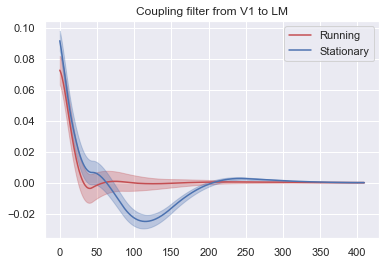

In [29]:
nbasis = pillow_basis_coupling.shape[1]
utils.plot_filter(pillow_basis_coupling, results_running.params[-nbasis:], 
                  results_running.bse[-nbasis:], label='Running', color='r')
utils.plot_filter(pillow_basis_coupling, results_stationary.params[-nbasis:], 
                  results_stationary.bse[-nbasis:], label='Stationary', color='b')
plt.title('Coupling filter from V1 to LM')
plt.legend()

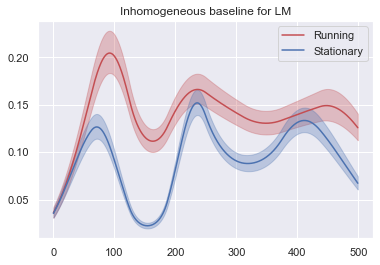

In [30]:
nbasis = X_baseline.shape[1]
utils.plot_filter(X_baseline[0:V1.nt,:], results_running.params[:nbasis], 
                  results_running.bse[:nbasis], label='Running', color='r',exp=True)
utils.plot_filter(X_baseline[0:V1.nt,:], results_stationary.params[:nbasis], 
                  results_stationary.bse[:nbasis], label='Stationary', color='b',exp=True)
plt.title('Inhomogeneous baseline for LM')
plt.legend()

([<matplotlib.axis.XTick at 0x1d9cc058bb0>,
 [Text(0, 0, '-500'),
  Text(250, 0, '-250'),
  Text(500, 0, '0'),
  Text(750, 0, '250'),
  Text(1000, 0, '500')])

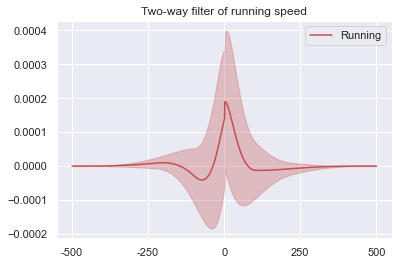

In [31]:
lbasis = 500
temp = np.zeros((2*lbasis+1))
temp[lbasis+1] = 1
X_speed_pos = GLM.conv(temp, pillow_basis, enforce_causality=True)
X_speed_neg = GLM.conv_flip(temp, pillow_basis, enforce_causality=False)
X_speed_pos[:,0] += X_speed_neg[:,0]
X_speed_neg = X_speed_neg[:,1:]
pillow_basis_twoway = np.hstack((X_speed_pos, X_speed_neg))

utils.plot_filter(pillow_basis_twoway, 
                  results_running.params[X_baseline.shape[1]:-pillow_basis_coupling.shape[1]], 
                  results_running.bse[X_baseline.shape[1]:-pillow_basis_coupling.shape[1]], 
                  label='Running', 
                  color='r')
# utils.plot_filter(pillow_basis_twoway, 
#                   results_stationary.params[X_baseline.shape[1]:-pillow_basis_coupling.shape[1]], 
#                   results_stationary.bse[X_baseline.shape[1]:-pillow_basis_coupling.shape[1]], 
#                   label='Stationary', 
#                   color='b')
plt.legend()
plt.title('Two-way filter of running speed')
plt.xticks([0, 250, 500, 750, 1000], np.array([0, 250, 500, 750, 1000])-500)

([<matplotlib.axis.XTick at 0x1d9c99138e0>,
 [Text(0, 0, '-500'),
  Text(250, 0, '-250'),
  Text(500, 0, '0'),
  Text(750, 0, '250'),
  Text(1000, 0, '500')])

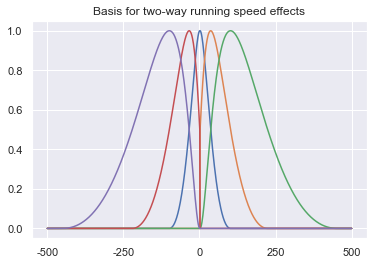

In [32]:
plt.plot(pillow_basis_twoway)
plt.title('Basis for two-way running speed effects')
plt.xticks([0, 250, 500, 750, 1000], np.array([0, 250, 500, 750, 1000])-500)

# Population coupling in running / stationary condition
Coupling effects + Inhomogeneous baseline + Running speed effects

Text(0.5, 0.98, 'Coupling filters ')

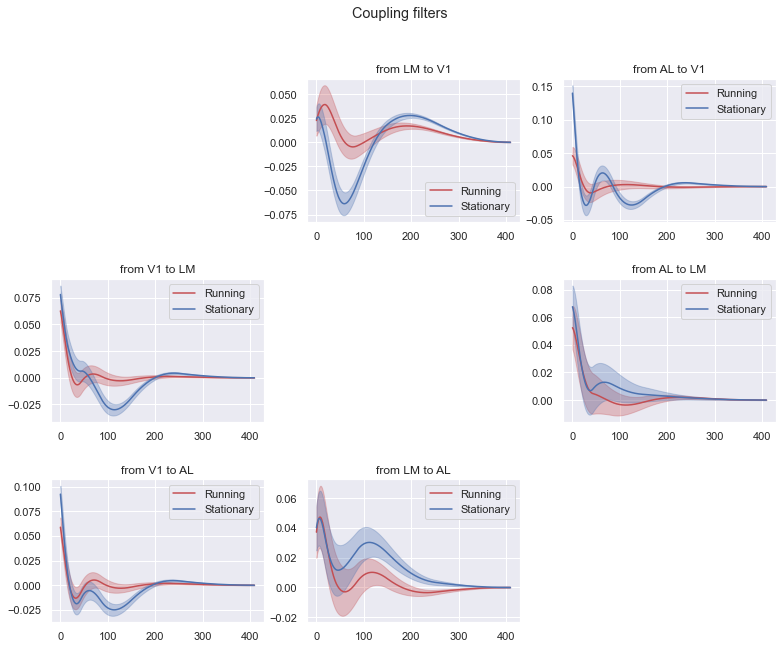

In [33]:
# coupling filter from i to j
import seaborn as sns
sns.set_theme()
probe_area = {'probeC':'V1', 'probeD':'LM', 'probeE':'AL'}

n_area = 3
fig = plt.figure(figsize=(13,10))
gs = fig.add_gridspec(n_area, n_area)
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.4)

j = 0
rcd_results_stationary = {}
rcd_results_running = {}
for i in range(n_area):
    output_probe = V1.selected_probes[i]
    input_probe_list = np.delete(V1.selected_probes, i)
    
    # Running
    selec_trials = V1.running_trial_index

    pillow_basis_coupling = GLM.make_pillow_basis(peaks_max=150, num=5, nonlinear=0.2, verbose=False)
    pillow_basis = GLM.make_pillow_basis(peaks_max=100, num=3, nonlinear=0.4, verbose=False)
    
    output_spike = utils.pooling_pop(membership, condition_ids, V1, output_probe, 0)[:,selec_trials]
    response = output_spike.flatten('F')
    
    # get predictors
    X_baseline = GLM.inhomo_baseline(ntrial=selec_trials.sum(), start=0, end=V1.nt, dt=1, num=15)
    effect_list = [X_baseline]
    
    for input_probe in input_probe_list:
        input_spike = utils.pooling_pop(membership, condition_ids, V1, input_probe, 0)[:,selec_trials]
        X_coupling = GLM.conv(input_spike, pillow_basis_coupling)
        effect_list.append(X_coupling)
    X_speed_pos = GLM.conv(V1.speed[:,selec_trials], pillow_basis, enforce_causality=True)
    X_speed_neg = GLM.conv_flip(V1.speed[:,selec_trials], pillow_basis, enforce_causality=False)
    X_speed_pos[:,0] += X_speed_neg[:,0]
    X_speed_neg = X_speed_neg[:,1:]
    effect_list.append(X_speed_pos)
    effect_list.append(X_speed_neg)
    
    predictors = np.hstack(effect_list)
    
    # fit model
    results_running = sm.GLM(response, predictors, family=sm.families.Poisson()).fit()
    
    # Stationary
    selec_trials = V1.stationary_trial_index
    
    output_spike = utils.pooling_pop(membership, condition_ids, V1, output_probe, 0)[:,selec_trials]
    response = output_spike.flatten('F')
    
    # get predictors
    X_baseline = GLM.inhomo_baseline(ntrial=selec_trials.sum(), start=0, end=V1.nt, dt=1, num=15)
    effect_list = [X_baseline]
    
    for input_probe in input_probe_list:
        input_spike = utils.pooling_pop(membership, condition_ids, V1, input_probe, 0)[:,selec_trials]
        X_coupling = GLM.conv(input_spike, pillow_basis_coupling)
        effect_list.append(X_coupling)
    X_speed_pos = GLM.conv(V1.speed[:,selec_trials], pillow_basis, enforce_causality=True)
    X_speed_neg = GLM.conv_flip(V1.speed[:,selec_trials], pillow_basis, enforce_causality=False)
    X_speed_pos[:,0] += X_speed_neg[:,0]
    X_speed_neg = X_speed_neg[:,1:]
    effect_list.append(X_speed_pos)
    effect_list.append(X_speed_neg)
    
    predictors = np.hstack(effect_list)
    
    # fit model
    results_stationary = sm.GLM(response, predictors, family=sm.families.Poisson()).fit()
    
    # plot coupling filter
    j_toplot = 0
    for j in range(n_area):
        if j==i:
            continue
        fig.add_subplot(gs[i, j])
        nbasis_baseline = X_baseline.shape[1]
        nbasis_coupling = pillow_basis_coupling.shape[1]
        utils.plot_filter(pillow_basis_coupling, 
                          results_running.params[(nbasis_baseline+j_toplot*nbasis_coupling):
                                                 (nbasis_baseline+j_toplot*nbasis_coupling+nbasis_coupling)], 
                          results_running.bse[(nbasis_baseline+j_toplot*nbasis_coupling):
                                              (nbasis_baseline+j_toplot*nbasis_coupling+nbasis_coupling)], 
                          label='Running', 
                          color='r')
        utils.plot_filter(pillow_basis_coupling, 
                          results_stationary.params[(nbasis_baseline+j_toplot*nbasis_coupling):
                                                 (nbasis_baseline+j_toplot*nbasis_coupling+nbasis_coupling)], 
                          results_stationary.bse[(nbasis_baseline+j_toplot*nbasis_coupling):
                                              (nbasis_baseline+j_toplot*nbasis_coupling+nbasis_coupling)], 
                          label='Stationary', 
                          color='b')
        j_toplot += 1
        plt.title(f"from {probe_area[input_probe_list[j_toplot-1]]} to {probe_area[output_probe]}")
        plt.legend()
    # save results
    rcd_results_stationary[i] = results_stationary
    rcd_results_running[i] = results_running
plt.suptitle(f"Coupling filters ")

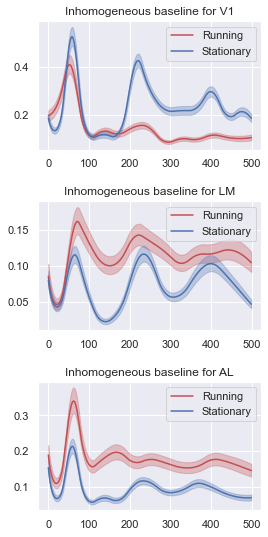

In [34]:
fig = plt.figure(figsize=(4,9))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.4)
for i in range(n_area):
    plt.subplot(3,1,i+1)
    nbasis = X_baseline.shape[1]
    results_running = rcd_results_running[i]
    results_stationary = rcd_results_stationary[i]
    utils.plot_filter(X_baseline[0:V1.nt,:], results_running.params[:nbasis], 
                      results_running.bse[:nbasis], label='Running', color='r',exp=True)
    utils.plot_filter(X_baseline[0:V1.nt,:], results_stationary.params[:nbasis], 
                      results_stationary.bse[:nbasis], label='Stationary', color='b',exp=True)
    plt.title(f'Inhomogeneous baseline for {probe_area[V1.selected_probes[i]]}')
    plt.legend()

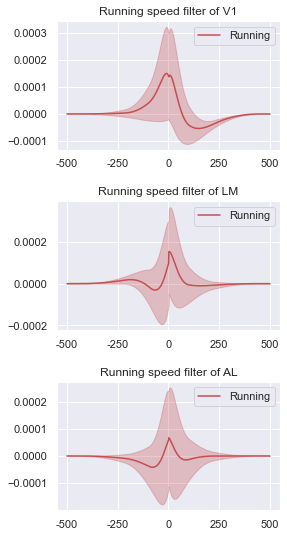

In [35]:
fig = plt.figure(figsize=(4,9))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.4)

lbasis = 500
temp = np.zeros((2*lbasis+1))
temp[lbasis+1] = 1
X_speed_pos = GLM.conv(temp, pillow_basis, enforce_causality=True)
X_speed_neg = GLM.conv_flip(temp, pillow_basis, enforce_causality=False)
X_speed_pos[:,0] += X_speed_neg[:,0]
X_speed_neg = X_speed_neg[:,1:]
pillow_basis_twoway = np.hstack((X_speed_pos, X_speed_neg))
for i in range(n_area):
    plt.subplot(3,1,i+1)
    nbasis = pillow_basis_twoway.shape[1]
    results_running = rcd_results_running[i]
    results_stationary = rcd_results_stationary[i]
    utils.plot_filter(pillow_basis_twoway, 
                      results_running.params[-nbasis:], 
                      results_running.bse[-nbasis:], 
                      label='Running', 
                      color='r')
    plt.title(f'Running speed filter of {probe_area[V1.selected_probes[i]]}')
    plt.legend()
    plt.xticks([0, 250, 500, 750, 1000], np.array([0, 250, 500, 750, 1000])-500)
    




In [286]:
# number of running
np.sum(V1.running_trial_index)

5

In [287]:
# number of stationary
np.sum(V1.stationary_trial_index)

10

Text(0.5, 1.0, 'Distribution of mean running speed')

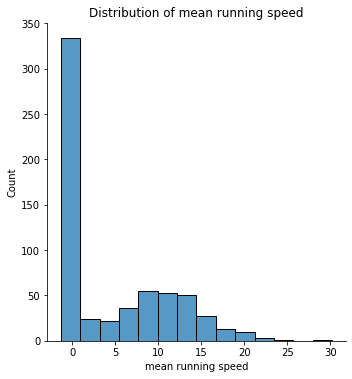

In [6]:
import seaborn as sns
sns.displot(V1.mean_speed)
plt.xlabel('mean running speed')
plt.title('Distribution of mean running speed')

# Power Spectrum under Running / Stationary

In [9]:
# Load LFP data
from rCSD import CSD, Allen_dataset
import utility_functions as utils
import matplotlib.pyplot as plt

start_time = 0.0
end_time = 0.35
padding = 0.1
V1 = Allen_dataset(fps=500,
                   start_time=start_time-padding, 
                   end_time=end_time+padding,
#                    orientation=[0],
                   session_id=757216464,
                   probe_id=769322749, 
#                    temporal_frequency=[1,2,4],
#                    stimulus_condition_id=[250,251,258],
                   stimulus_name='drifting_gratings')
V1.get_lfp()
V1.get_running()

LM = Allen_dataset(fps=500,
                   start_time=start_time-padding, 
                   end_time=end_time+padding,
#                    orientation=[0],
                   session_id=757216464,
                   probe_id=769322751, 
#                    temporal_frequency=[1,2,4],
#                    stimulus_condition_id=[250,251,258],
                   stimulus_name='drifting_gratings')
LM.get_lfp()
LM.get_running()

AL = Allen_dataset(fps=500,
                   start_time=start_time-padding, 
                   end_time=end_time+padding,
#                    orientation=[0],
                   session_id=757216464,
                   probe_id=769322753, 
#                    temporal_frequency=[1,2,4],
#                    stimulus_condition_id=[250,251,258],
                   stimulus_name='drifting_gratings')
AL.get_lfp()
AL.get_running()

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)


5.454545454545454


(-10.0, 150.0)

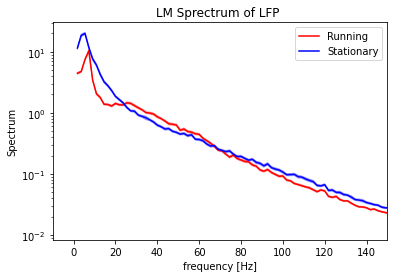

In [50]:
csd = CSD(LM)
csd.plot_spectrum_running()
plt.title('LM Sprectrum of LFP ')
plt.xlim((-10, 150))

5.454545454545454


(-10.0, 150.0)

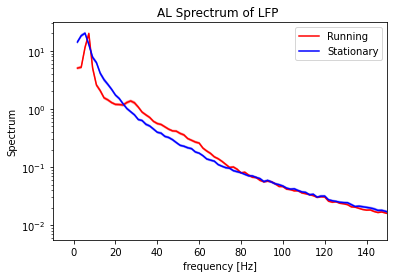

In [51]:
csd = CSD(AL)
csd.plot_spectrum_running()
plt.title('AL Sprectrum of LFP ')
plt.xlim((-10, 150))

5.454545454545454


(-10.0, 150.0)

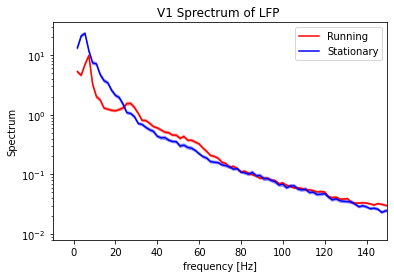

In [16]:
from rCSD import CSD, Allen_dataset
csd = CSD(V1)
csd.plot_spectrum_running()
plt.title('V1 Sprectrum of LFP ')
plt.xlim((-10, 150))

3.6363636363636362


(-10.0, 150.0)

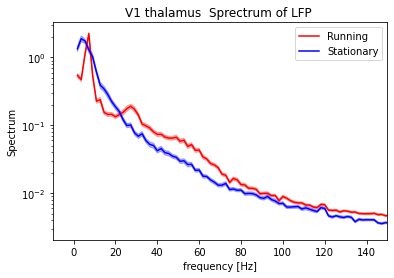

In [17]:
csd.plot_spectrum_running(channel=np.arange(20))
plt.title('V1 thalamus  Sprectrum of LFP ')
plt.xlim((-10, 150))

3.6363636363636362


(-10.0, 150.0)

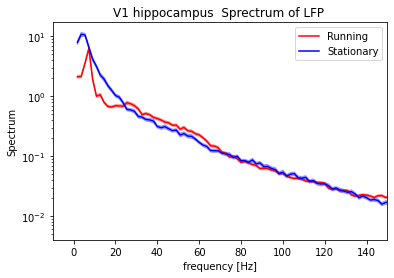

In [18]:
csd.plot_spectrum_running(channel=np.arange(20,61))
plt.title('V1 hippocampus  Sprectrum of LFP ')
plt.xlim((-10, 150))

5.454545454545454


(-10.0, 150.0)

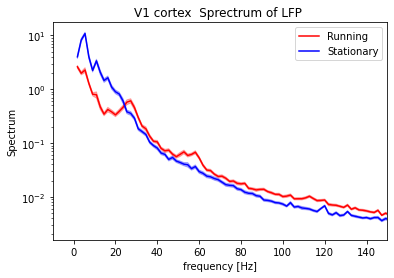

In [19]:
csd.plot_spectrum_running(channel=np.arange(61,93))
plt.title('V1 cortex  Sprectrum of LFP ')
plt.xlim((-10, 150))

## Gamma Power 20-60Hz vs Running Speed

In [20]:
import copy
def get_power_phase(data, npadding, lowcut, highcut):
    data = copy.copy(data)
    nx, nt, ntrial = data.shape
    phase = np.zeros((nx, nt-2*npadding, ntrial))
    power = np.zeros((nx, nt-2*npadding, ntrial))

    for itrial in range(ntrial):
        raw_signal = data[:,:,itrial]
        instantaneous_phase, instantaneous_power = utils.get_phase(raw_signal, 500, lowcut=lowcut, highcut=highcut, 
                                                                   npadding=npadding)
        phase[:,:,itrial] = instantaneous_phase
        power[:,:,itrial] = instantaneous_power
    return phase, power

Text(0, 0.5, 'Power')

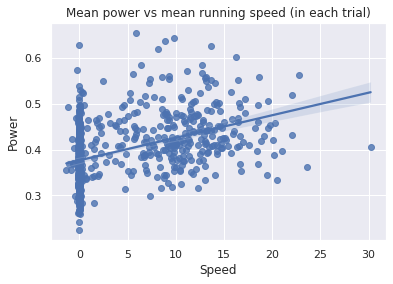

In [21]:
phase, power = get_power_phase(csd.y, npadding=50, lowcut=20.0, highcut=60.0)
mean_power = power.mean(axis=(0,1))
import seaborn as sns
sns.set_theme(color_codes=True)
ax = sns.regplot(x=V1.mean_speed, y=mean_power)
plt.title("Mean power vs mean running speed (in each trial)")
plt.xlabel("Speed")
plt.ylabel("Power")

Text(0, 0.5, 'Power')

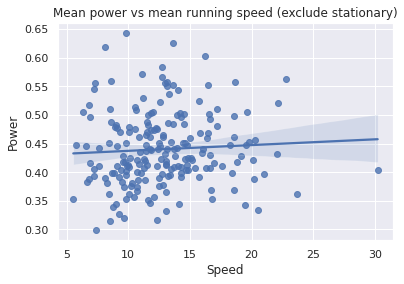

In [22]:
phase, power = get_power_phase(csd.y[:,:,csd.running_trial_index], npadding=50, lowcut=20.0, highcut=60.0)
mean_power = power.mean(axis=(0,1))

sns.set_theme(color_codes=True)
ax = sns.regplot(x=V1.mean_speed[csd.running_trial_index], y=mean_power)
plt.title("Mean power vs mean running speed (exclude stationary)")
plt.xlabel("Speed")
plt.ylabel("Power")

## Power as a function of time (Match Yu Chen's two peaks!)

Text(0, 0.5, 'Power')

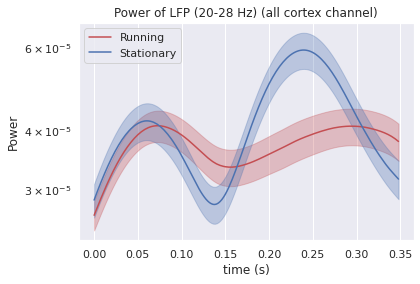

In [52]:
highcut = 28
lowcut = 20

from rCSD import CSD, Allen_dataset
import seaborn as sns
sns.set_theme()
csd = CSD(V1)
channel_id = np.arange(61,93)

phase, power = get_power_phase(V1.lfp[:,:,V1.running_trial_index], npadding=50, lowcut=lowcut, highcut=highcut)
x = np.arange(0, 0.35, 1/500)
y = power[channel_id,:,:].mean(axis=(0,2))
ci = power[channel_id,:,:].std(axis=(0,2))/np.sqrt(power.shape[2])
plt.semilogy(x, y,label='Running', color='r')
plt.fill_between(x, (y-ci), (y+ci), color='r', alpha=.3)

phase, power = get_power_phase(V1.lfp[:,:,V1.stationary_trial_index], npadding=50, lowcut=lowcut, highcut=highcut)
x = np.arange(0, 0.35, 1/500)
y = power[channel_id,:,:].mean(axis=(0,2))
ci = power[channel_id,:,:].std(axis=(0,2))/np.sqrt(power.shape[2])
plt.semilogy(x, y,label='Stationary', color='b')
plt.fill_between(x, (y-ci), (y+ci), color='b', alpha=.3)

plt.legend()
plt.title('Power of LFP (%2.f-%2.f Hz) (all cortex channel)'%(lowcut,highcut))
plt.xlabel('time (s)')
plt.ylabel('Power')

Text(0, 0.5, 'Power')

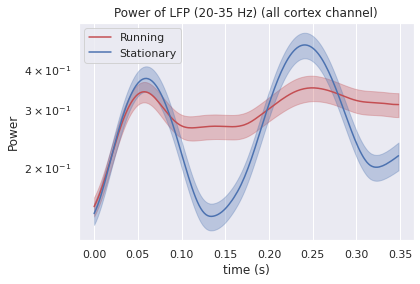

In [23]:
channel_id = np.arange(61,93)

phase, power = get_power_phase(csd.y[:,:,csd.running_trial_index], npadding=50, lowcut=20.0, highcut=35.0)
x = np.arange(0, 0.35, 1/500)
y = power[channel_id,:,:].mean(axis=(0,2))
ci = power[channel_id,:,:].std(axis=(0,2))/np.sqrt(power.shape[2])
plt.semilogy(x, y,label='Running', color='r')
plt.fill_between(x, (y-ci), (y+ci), color='r', alpha=.3)

phase, power = get_power_phase(csd.y[:,:,csd.stationary_trial_index], npadding=50, lowcut=20.0, highcut=35.0)
x = np.arange(0, 0.35, 1/500)
y = power[channel_id,:,:].mean(axis=(0,2))
ci = power[channel_id,:,:].std(axis=(0,2))/np.sqrt(power.shape[2])
plt.semilogy(x, y,label='Stationary', color='b')
plt.fill_between(x, (y-ci), (y+ci), color='b', alpha=.3)

plt.legend()
plt.title('Power of LFP (20-35 Hz) (all cortex channel)')
plt.xlabel('time (s)')
plt.ylabel('Power')

Text(0, 0.5, 'Power')

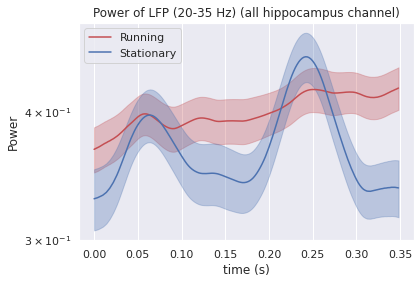

In [24]:
channel_id = np.arange(20,61)

phase, power = get_power_phase(csd.y[:,:,csd.running_trial_index], npadding=50, lowcut=20.0, highcut=35.0)
x = np.arange(0, 0.35, 1/500)
y = power[channel_id,:,:].mean(axis=(0,2))
ci = power[channel_id,:,:].std(axis=(0,2))/np.sqrt(power.shape[2])
plt.semilogy(x, y,label='Running', color='r')
plt.fill_between(x, (y-ci), (y+ci), color='r', alpha=.3)

phase, power = get_power_phase(csd.y[:,:,csd.stationary_trial_index], npadding=50, lowcut=20.0, highcut=35.0)
x = np.arange(0, 0.35, 1/500)
y = power[channel_id,:,:].mean(axis=(0,2))
ci = power[channel_id,:,:].std(axis=(0,2))/np.sqrt(power.shape[2])
plt.semilogy(x, y,label='Stationary', color='b')
plt.fill_between(x, (y-ci), (y+ci), color='b', alpha=.3)

plt.legend()
plt.title('Power of LFP (20-35 Hz) (all hippocampus channel)')
plt.xlabel('time (s)')
plt.ylabel('Power')

Text(0, 0.5, 'Power')

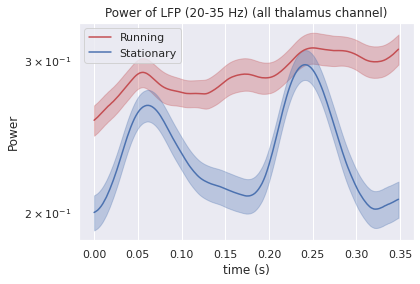

In [25]:
channel_id = np.arange(0,20)

phase, power = get_power_phase(csd.y[:,:,csd.running_trial_index], npadding=50, lowcut=20.0, highcut=35.0)
x = np.arange(0, 0.35, 1/500)
y = power[channel_id,:,:].mean(axis=(0,2))
ci = power[channel_id,:,:].std(axis=(0,2))/np.sqrt(power.shape[2])
plt.semilogy(x, y,label='Running', color='r')
plt.fill_between(x, (y-ci), (y+ci), color='r', alpha=.3)

phase, power = get_power_phase(csd.y[:,:,csd.stationary_trial_index], npadding=50, lowcut=20.0, highcut=35.0)
x = np.arange(0, 0.35, 1/500)
y = power[channel_id,:,:].mean(axis=(0,2))
ci = power[channel_id,:,:].std(axis=(0,2))/np.sqrt(power.shape[2])
plt.semilogy(x, y,label='Stationary', color='b')
plt.fill_between(x, (y-ci), (y+ci), color='b', alpha=.3)

plt.legend()
plt.title('Power of LFP (20-35 Hz) (all thalamus channel)')
plt.xlabel('time (s)')
plt.ylabel('Power')

## Time domain

Text(0, 0.5, 'LFP ')

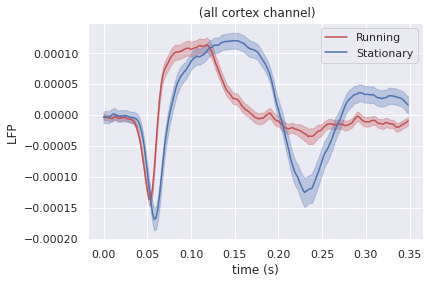

In [53]:
channel_id = np.arange(61,93)

data = V1.lfp[:,50:225,V1.running_trial_index]

x = np.arange(0, 0.35, 1/500)
y = data[channel_id,:,:].mean(axis=(0,2))
ci = data[channel_id,:,:].std(axis=(0,2))/np.sqrt(data.shape[2])
plt.plot(x, y,label='Running', color='r')
plt.fill_between(x, (y-ci), (y+ci), color='r', alpha=.3)

data = V1.lfp[:,50:225,V1.stationary_trial_index]
x = np.arange(0, 0.35, 1/500)
y = data[channel_id,:,:].mean(axis=(0,2))
ci = data[channel_id,:,:].std(axis=(0,2))/np.sqrt(data.shape[2])
plt.plot(x, y,label='Stationary', color='b')
plt.fill_between(x, (y-ci), (y+ci), color='b', alpha=.3)

plt.legend()
plt.title(' (all cortex channel)')
plt.xlabel('time (s)')
plt.ylabel('LFP ')

Text(0, 0.5, 'LFP ')

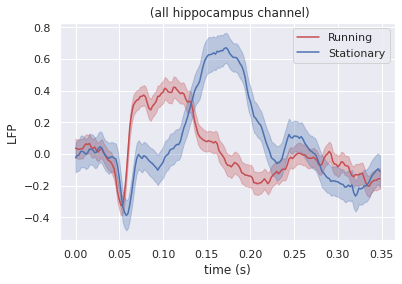

In [27]:
channel_id = np.arange(20,61)

data = csd.y[:,50:225,csd.running_trial_index]

x = np.arange(0, 0.35, 1/500)
y = data[channel_id,:,:].mean(axis=(0,2))
ci = data[channel_id,:,:].std(axis=(0,2))/np.sqrt(data.shape[2])
plt.plot(x, y,label='Running', color='r')
plt.fill_between(x, (y-ci), (y+ci), color='r', alpha=.3)

data = csd.y[:,50:225,csd.stationary_trial_index]
x = np.arange(0, 0.35, 1/500)
y = data[channel_id,:,:].mean(axis=(0,2))
ci = data[channel_id,:,:].std(axis=(0,2))/np.sqrt(data.shape[2])
plt.plot(x, y,label='Stationary', color='b')
plt.fill_between(x, (y-ci), (y+ci), color='b', alpha=.3)

plt.legend()
plt.title(' (all hippocampus channel)')
plt.xlabel('time (s)')
plt.ylabel('LFP ')

Text(0, 0.5, 'LFP ')

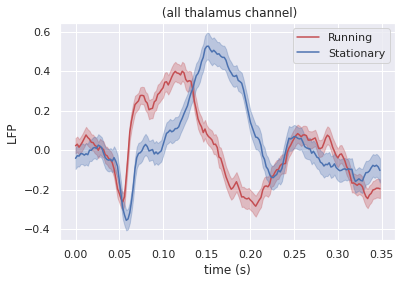

In [28]:
channel_id = np.arange(0,20)

data = csd.y[:,50:225,csd.running_trial_index]

x = np.arange(0, 0.35, 1/500)
y = data[channel_id,:,:].mean(axis=(0,2))
ci = data[channel_id,:,:].std(axis=(0,2))/np.sqrt(data.shape[2])
plt.plot(x, y,label='Running', color='r')
plt.fill_between(x, (y-ci), (y+ci), color='r', alpha=.3)

data = csd.y[:,50:225,csd.stationary_trial_index]
x = np.arange(0, 0.35, 1/500)
y = data[channel_id,:,:].mean(axis=(0,2))
ci = data[channel_id,:,:].std(axis=(0,2))/np.sqrt(data.shape[2])
plt.plot(x, y,label='Stationary', color='b')
plt.fill_between(x, (y-ci), (y+ci), color='b', alpha=.3)

plt.legend()
plt.title(' (all thalamus channel)')
plt.xlabel('time (s)')
plt.ylabel('LFP ')

# Load LFP from V1 LM AL

In [54]:
# lfp = np.vstack((V1.lfp, LM.lfp, AL.lfp))
gap = 3
lfp = np.vstack((V1.lfp[1:-1:gap,:,:], LM.lfp[1:-1:gap,:,:], AL.lfp[1:-1:gap,:,:])) 
# Then there's only 31, 31 ,32 channels left. 

In [55]:
lfp.shape

(94, 275, 630)

In [56]:
V1.structure_acronyms, V1.intervals_lfp

(array(['MGm', 'SGN', 'LP', 'DG', 'ProS', 'SUB', 'VISp', nan], dtype=object),
 array([ 0,  3,  9, 20, 38, 48, 61, 85, 93]))

In [57]:
LM.structure_acronyms, LM.intervals_lfp

(array(['TH', 'LGv', 'TH', 'CA3', 'DG', 'CA1', 'VISl', nan], dtype=object),
 array([ 0,  1,  7, 15, 30, 38, 60, 85, 93]))

In [58]:
AL.structure_acronyms, AL.intervals_lfp

(array(['PO', 'LP', 'LGd', 'CA3', 'DG', 'CA1', 'VISal', nan], dtype=object),
 array([ 0, 14, 27, 35, 41, 47, 63, 88, 96]))

In [59]:
probe_lines = np.add.accumulate([93,93,96])
probe_lines = np.floor((probe_lines-1)/gap) + 1
probe_text = ['V1 probe', 'LM probe', 'AL probe']
area_lines = np.array([20, 61, 93,
              93+15, 93+60, 93+93,
              93+93+35, 93+93+63, 93+93+96])
area_lines = np.floor((area_lines-1)/gap) + 1
# 上面的-1,（因为从1,4,7开始的）， 然后除3取floor() +1 （因为是右不包含区间）
area_text = ['Thalamus', 'Hippocampus', 'Cortex',
             'Thalamus', 'Hippocampus', 'Cortex',
             'Thalamus', 'Hippocampus', 'Cortex']

In [60]:
area_lines, probe_lines   # CHECK!

(array([ 7., 21., 31., 36., 51., 62., 74., 83., 94.]), array([31., 62., 94.]))

In [283]:
del V1, AL, LM

# Core functions

In [61]:
from tqdm import tqdm
from statsmodels.tsa.stattools import grangercausalitytests
from scipy import stats
from astropy.stats import circstats
import copy
from pyTG import torusGraphs

def fill_symmetric(nx, vec):
    inds = np.triu_indices(nx,1)
    mat = np.zeros((nx,nx))
    mat[inds] = vec
    mat = mat+mat.T
    np.fill_diagonal(mat, np.nan)
    return mat

def get_power_phase(data, npadding, lowcut, highcut):
    data = copy.copy(data)
    nx, nt, ntrial = data.shape
    phase = np.zeros((nx, nt-2*npadding, ntrial))
    power = np.zeros((nx, nt-2*npadding, ntrial))

    for itrial in range(ntrial):
        raw_signal = data[:,:,itrial]
        instantaneous_phase, instantaneous_power = utils.get_phase(raw_signal, 500, lowcut=lowcut, highcut=highcut, 
                                                                   npadding=npadding)
        phase[:,:,itrial] = instantaneous_phase
        power[:,:,itrial] = instantaneous_power
    return phase, power


def TG(data, out=None, nboot=10, quan=0.95):
    nx, nt, ntrial = data.shape
    if out=='p':
        pvalue_mat = np.nan*np.zeros((nx, nx))
        X = data.reshape((nx, nt*ntrial), order="F")
        graph, _, _, nodepairs, _, phi, phi_cov = torusGraphs(X, selMode = (False, True, False))
        pvalue_mat = fill_symmetric(nx, nodepairs['pVals'])

        from statsmodels.sandbox.stats.multicomp import multipletests
        adjusted_p = multipletests(pvalue_mat.ravel(), method='bonferroni')
        pvalue_mat = adjusted_p[1].reshape((nx, nx))
        log_pvalue_mat = np.log(pvalue_mat)
        log_pvalue_mat = np.nan_to_num(log_pvalue_mat)
        np.fill_diagonal(log_pvalue_mat, np.nan)
        return log_pvalue_mat
    else:
        pplv_mat_boot = np.nan*np.zeros((nx, nx, nboot))
        if nboot == 1:
            X = data.reshape((nx, nt*ntrial), order="F")
            graph, _, _, nodepairs, _, phi, phi_cov = torusGraphs(X, selMode = (False, True, False))
        else:
            for iboot in tqdm(range(nboot)):
                boot_sample = np.random.choice(ntrial, size=ntrial, replace=True)
                data_new = data[:,:,boot_sample]
                X = data_new.reshape((nx, nt*ntrial), order="F")
                graph, _, _, nodepairs, _, phi, phi_cov = torusGraphs(X, selMode = (False, True, False))
                pplv_mat_boot[:,:,iboot] = fill_symmetric(nx, nodepairs['condCoupling'])
        
        if nboot == 1:
            return fill_symmetric(nx, nodepairs['condCoupling'])
        else:
            pplv_mat_LB = np.quantile(pplv_mat_boot, (1-quan)/2, axis=2)
            np.fill_diagonal(pplv_mat_LB, np.nan)
            return pplv_mat_LB


def PLV(data, out=None, nboot=10, quan=0.95):
    nx, nt, ntrial = data.shape
    if out=='p':
        pvalue_mat = np.nan*np.zeros((nx, nx))
        for channel1 in tqdm(range(nx)):
            for channel2 in range(nx):
                
                pvalue_mat[channel1, channel2] = circstats.rayleightest(phase_diff, 
                                                                        axis=None, weights=None)
        from statsmodels.sandbox.stats.multicomp import multipletests
        adjusted_p = multipletests(pvalue_mat.ravel(), method='bonferroni')
        pvalue_mat = adjusted_p[1].reshape((nx, nx))
        log_pvalue_mat = np.log(pvalue_mat)
        log_pvalue_mat = np.nan_to_num(log_pvalue_mat)
        np.fill_diagonal(log_pvalue_mat, np.nan)
        log_pvalue_mat_phase = log_pvalue_mat
        return log_pvalue_mat_phase
    else:
        plv_mat_boot = np.nan*np.zeros((nx, nx, nboot))
        for iboot in tqdm(range(nboot)):
            boot_sample = np.random.choice(ntrial, size=ntrial, replace=True)
            data_new = data[:,:,boot_sample]
            for channel1 in range(nx):
                for channel2 in range(nx):
                    phase_diff = data_new[channel1,:,:]-data_new[channel2,:,:]
                    plv_mat_boot[channel1, channel2,iboot] = np.sqrt( (np.sin(phase_diff)).mean()**2 
                                                     + (np.cos(phase_diff)).mean()**2 )
        plv_mat_LB = np.quantile(plv_mat_boot, (1-quan)/2, axis=2)
        np.fill_diagonal(plv_mat_LB, np.nan)
        return plv_mat_LB


def LaDyns(data, out=None):
#     log_pvalue_mat_power = granger(power, npadding=0, maxlag=maxlag)
    pass



def granger(data, npadding, maxlag, out=None, nboot=10, quan=0.95):
    data = copy.copy(data)
    if npadding>0:
        data = data[:,npadding:-npadding,:]
    nx, nt, ntrial = data.shape
    if out=='p':
        chi_mat = np.zeros((nx, nx))
        pvalue_mat = np.nan*np.zeros((nx, nx))
    else:
        rdiff_mat = np.nan*np.zeros((nx, nx, ntrial))
        rdiff_mat_LB = np.nan*np.zeros((nx, nx))
        rdiff_mat_boot = np.nan*np.zeros((nx, nx, nboot))
    for channel1 in tqdm(range(nx)):
        for channel2 in range(nx):
            if channel1 != channel2:
                for itrial in range(ntrial):
                    ts_cause = data[channel1,:,itrial]
                    ts_result = data[channel2,:,itrial]
                    g_results = grangercausalitytests(np.vstack((ts_result, ts_cause)).T, 
                                                      maxlag=[maxlag], verbose=False)
                    if out=='p':
                        chi_mat[channel1, channel2] += g_results[maxlag][0]['lrtest'][0]
                    else:
                        model1_res = g_results[maxlag][1][0].mse_resid*g_results[maxlag][1][0].df_resid
                        model2_res = g_results[maxlag][1][1].mse_resid*g_results[maxlag][1][1].df_resid
                        rdiff_mat[channel1, channel2, itrial] = (model1_res-model2_res)/(model1_res)
                if out=='p':
                    pvalue_mat[channel1, channel2] = 1 - stats.chi2.cdf(chi_mat[channel1, channel2],
                                                                        ntrial*g_results[maxlag][0]['lrtest'][2])
    

        
    if out=='p':
        from statsmodels.sandbox.stats.multicomp import multipletests
        adjusted_p = multipletests(pvalue_mat.ravel(), method='bonferroni')
        pvalue_mat = adjusted_p[1].reshape((nx, nx))
        log_pvalue_mat = np.log(pvalue_mat)
        log_pvalue_mat = np.nan_to_num(log_pvalue_mat)
        np.fill_diagonal(log_pvalue_mat, np.nan)
        return log_pvalue_mat
    else:
        
        for iboot in range(nboot):
            boot_sample = np.random.choice(ntrial, size=ntrial, replace=True)
            rdiff_mat_new = rdiff_mat[:,:,boot_sample]
            rdiff_mat_boot[:,:,iboot] = rdiff_mat_new.mean(axis=2)
        rdiff_mat_LB = np.quantile(rdiff_mat_boot, (1-quan)/2, axis=2)
        return rdiff_mat_LB, rdiff_mat
    

        


In [62]:
def myplot(result, title='', clim=[0,1], gap=3):
    plt.rcParams['font.size'] = '15'
    probe_lines = np.add.accumulate([93,93,96])
    probe_lines = np.floor((probe_lines-1)/gap) + 1
    probe_text = ['V1 probe', 'LM probe', 'AL probe']
    area_lines = np.array([20, 61, 93,
                  93+15, 93+60, 93+93,
                  93+93+35, 93+93+63, 93+93+96])
    area_lines = np.floor((area_lines-1)/gap) + 1
    # 上面的-1,（因为从1,4,7开始的）， 然后除3取floor() +1 （因为是右不包含区间）
    area_text = ['Thalamus', 'Hippocampus', 'Cortex',
                 'Thalamus', 'Hippocampus', 'Cortex',
                 'Thalamus', 'Hippocampus', 'Cortex']
    
    nx = result.shape[0]
    f, ax = plt.subplots(1,1,figsize=(10, 8.5))
    im = plt.imshow(result, aspect='auto', cmap='rainbow')
    plt.title(title)
    plt.clim(clim[0],clim[1])
    clb2 = f.colorbar(im)
    clb2.ax.set_title('')
    
    # Plot probe segmentation
    lines = area_lines-0.5
    label_text = area_text
    for i in range(len(lines)-1):
        line_pos = lines[i]
        plt.hlines(line_pos, xmin=-0.5, xmax=nx-0.5, linestyles='dashed', 
                   linewidth=2, color='black', alpha=0.8)
        plt.vlines(line_pos, ymin=-0.5, ymax=nx-0.5, linestyles='dashed', 
                   linewidth=2, color='black', alpha=0.8)
    lines = np.insert(lines,0,0)
    label_x = [(lines[i]+lines[i+1])/2 for i in range(len(lines)-1)]
    ax.set_xticks(label_x)
    ax.set_xticklabels(label_text)
    ax.set_yticks(label_x)
    ax.set_yticklabels(label_text)
    plt.xticks(rotation = 45)
    
    # Plot probe segmentation
    lines = probe_lines-0.5
    label_text = probe_text
    for i in range(len(lines)-1):
        line_pos = lines[i]
        plt.hlines(line_pos, xmin=-0.5, xmax=nx-0.5, linestyles='solid', 
                   linewidth=2, color='black', alpha=0.8)
        plt.vlines(line_pos, ymin=-0.5, ymax=nx-0.5, linestyles='solid', 
                   linewidth=2, color='black', alpha=0.8)
    lines = np.insert(lines,0,0)
    label_x = [(lines[i]+lines[i+1])/2 for i in range(len(lines)-1)]
    for i in range(len(label_x)):
        text = label_text[i]
        pos = label_x[i]
        plt.text(pos-21/gap, 360/gap, text)
        plt.text(-90/gap, pos, text[0:2])
#     ax.set_xticks(label_x)
#     ax.set_xticklabels(label_text)
#     ax.set_yticks(label_x)
#     ax.set_yticklabels(label_text)
#     plt.gca().invert_yaxis()
#     plt.gca().invert_xaxis()

# Time domain

## Granger when stationary

In [203]:
rdiff_mat_LB, rdiff_mat = granger(lfp[:,:,csd.stationary_trial_index], npadding=50, maxlag=25)

100%|█████████████████████████████████████████████████████████████| 94/94 [2:35:58<00:00, 99.55s/it]


/tmp/ipykernel_105256/3249341377.py:20: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  clb2 = f.colorbar(im)


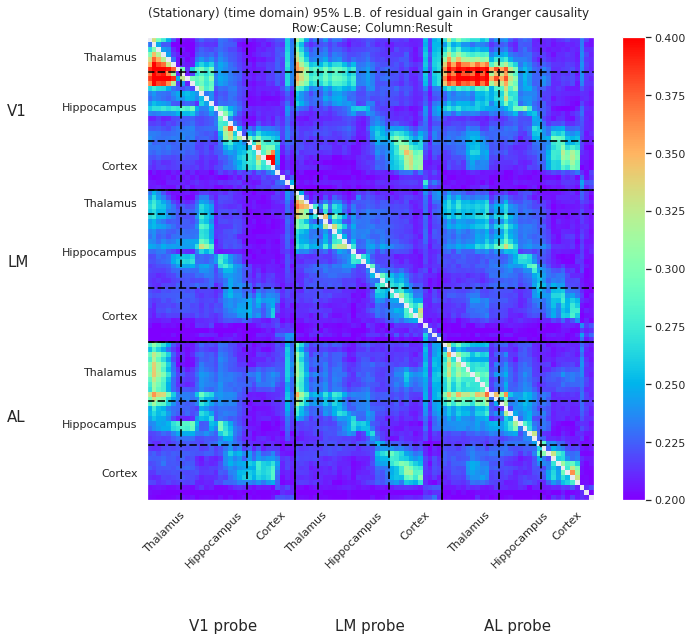

In [208]:
myplot(rdiff_mat_LB,
       title="(Stationary) (time domain) 95% L.B. of residual gain in Granger causality \n Row:Cause; Column:Result",
       clim=[0.2,0.4])
plt.grid(False)

## Granger when running

In [205]:
rdiff_mat_LB2, rdiff_mat2 = granger(lfp[:,:,csd.running_trial_index], npadding=50, maxlag=25)

100%|█████████████████████████████████████████████████████████████| 94/94 [2:15:47<00:00, 86.68s/it]


/tmp/ipykernel_105256/3249341377.py:20: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  clb2 = f.colorbar(im)


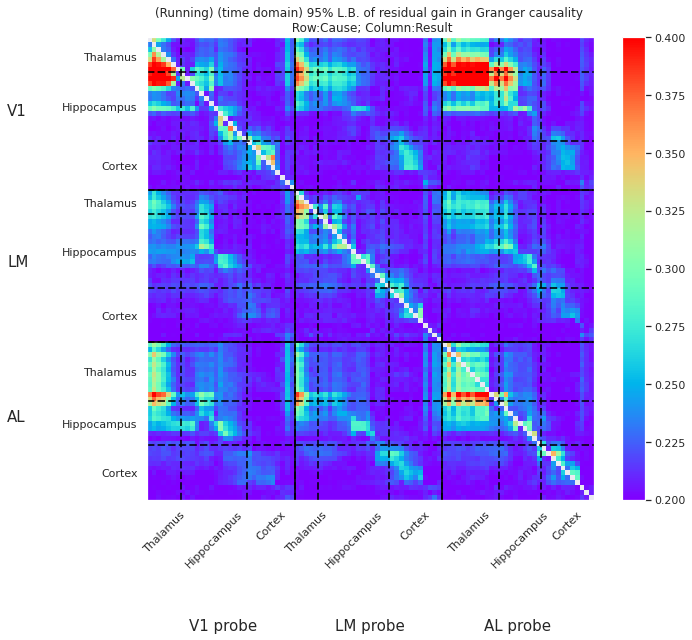

In [207]:
myplot(rdiff_mat_LB2,
       title="(Running) (time domain) 95% L.B. of residual gain in Granger causality \n Row:Cause; Column:Result",
       clim=[0.2,0.4])
plt.grid(False)

# Beta band

## Phase PLV when stationary

In [184]:
phase, power = get_power_phase(lfp[:,:,V1.stationary_trial_index], npadding=50, lowcut=lowcut, highcut=highcut)
plv_mat_LB = PLV(phase)


100%|███████████████████████████████████████████████████████████████| 10/10 [02:50<00:00, 17.08s/it]


/tmp/ipykernel_113440/3249341377.py:20: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  clb2 = f.colorbar(im)


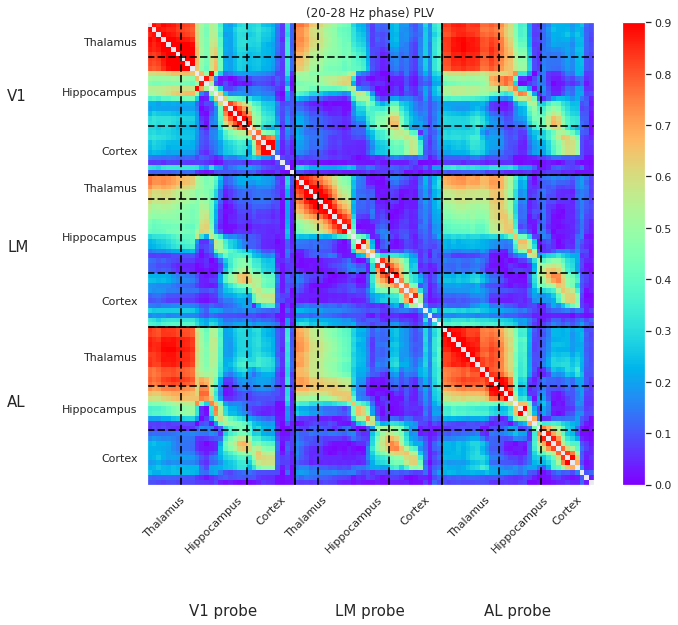

In [68]:
myplot(plv_mat_LB,
       title='(%2.f-%2.f Hz phase) PLV'%(lowcut,highcut),
       clim=[0.0,0.9])
plt.grid(False)


## Phase PLV when running

In [69]:
phase, power = get_power_phase(lfp[:,:,V1.running_trial_index], npadding=50, lowcut=lowcut, highcut=highcut)
plv_mat_LB = PLV(phase)

100%|███████████████████████████████████████████████████████████████| 10/10 [01:39<00:00,  9.92s/it]


/tmp/ipykernel_113440/3249341377.py:20: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  clb2 = f.colorbar(im)


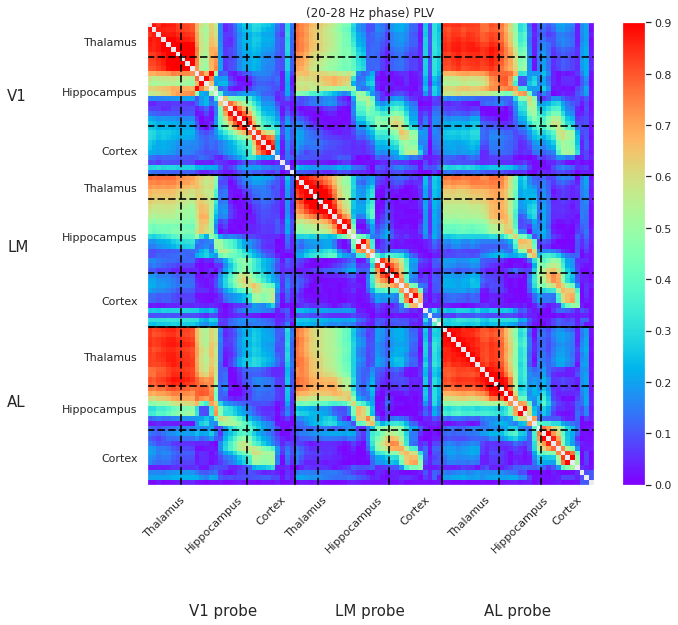

In [70]:
myplot(plv_mat_LB,
       title='(%2.f-%2.f Hz phase) PLV'%(lowcut,highcut),
       clim=[0.0,0.9])
plt.grid(False)

# Beta band

## TG when stationary

In [91]:
phase, power = get_power_phase(lfp[:,:,V1.stationary_trial_index], npadding=50, lowcut=lowcut, highcut=highcut)
plv_mat_LB = TG(phase[0:-1:3,:,:])


100%|████████████████████████████████████████████████████████████| 10/10 [1:14:07<00:00, 444.73s/it]


/tmp/ipykernel_113440/3249341377.py:20: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  clb2 = f.colorbar(im)


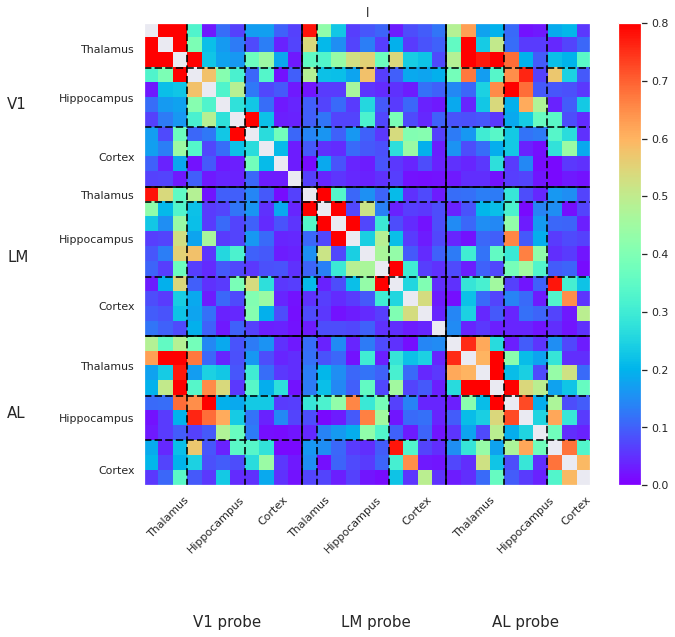

In [95]:
myplot(plv_mat_LB,
       title='l',
       clim=[0.0,0.8],
       gap=3*3)
plt.grid(False)


## TG when running

In [96]:
phase, power = get_power_phase(lfp[:,:,V1.running_trial_index], npadding=50, lowcut=lowcut, highcut=highcut)
plv_mat_LB = TG(phase[0:-1:3,:,:])

100%|████████████████████████████████████████████████████████████| 10/10 [1:28:50<00:00, 533.04s/it]


/tmp/ipykernel_113440/3249341377.py:20: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  clb2 = f.colorbar(im)


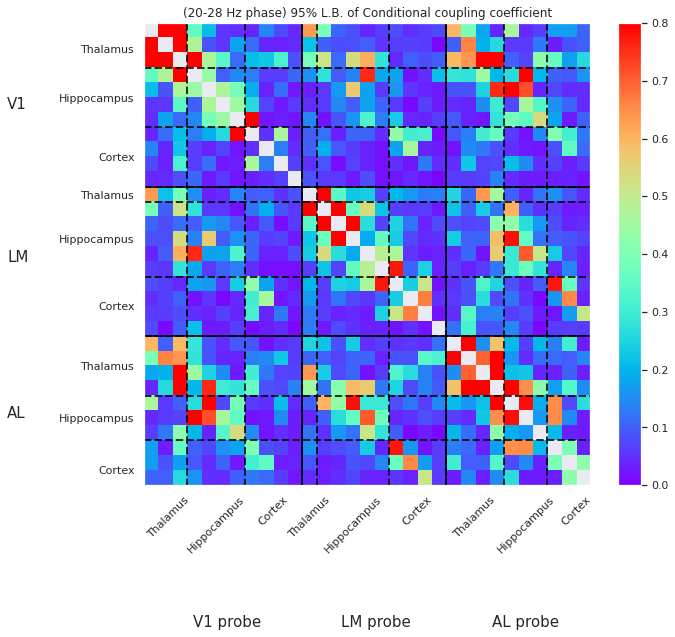

In [99]:
myplot(plv_mat_LB,
       title='(%2.f-%2.f Hz phase) 95%% L.B. of Conditional coupling coefficient'%(lowcut,highcut),
       clim=[0.0,0.8],
       gap=3*3)
plt.grid(False)